# Final Strict imbalance handling comparison with pAUC@88

이 notebook은 `Strict (최종 메인 세트)`에서 극단적 class imbalance를 어떻게 다룰지 비교하기 위한 실험 notebook이다.

비교 대상은 다음 3가지다.
1. `class_weight`: 원본 train 분포 유지 + CatBoost `auto_class_weights='Balanced'`
2. `random_oversampling`: malignant row를 단순 복제해 positive 비율을 높임
3. `patient_aware_oversampling`: malignant row를 복제하되, positive row가 많은 환자가 과도하게 반복되지 않도록 patient-aware 가중치를 둠

기본 평가지표는 `pAUC@TPR>=0.88`이며, threshold는 validation에서 `TPR>=0.88`을 만족하면서 specificity가 가장 높은 값으로 정한다.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, auc, roc_auc_score, average_precision_score, log_loss, brier_score_loss, precision_score, recall_score, f1_score, balanced_accuracy_score, confusion_matrix
from catboost import CatBoostClassifier, Pool

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

base_dir = Path('/home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024')
input_dir = base_dir / 'model_inputs'
out_dir = base_dir / 'modeling' / 'final_strict_imbalance_handling_catboost'
out_dir.mkdir(parents=True, exist_ok=True)
manifest_path = input_dir / 'strict_full_vs_final_strict_feature_manifest.json'

random_state = 42
PRIMARY_MIN_TPR = 0.88
SECONDARY_MIN_TPR = 0.80
OVERSAMPLING_TARGET_POSITIVE_FRACTION = 0.20

DISPLAY_NAME = {
    'class_weight': 'Class weight',
    'random_oversampling': 'Random oversampling',
    'patient_aware_oversampling': 'Patient-aware oversampling',
}
DISPLAY_COLOR = {
    'class_weight': '#4C78A8',
    'random_oversampling': '#F58518',
    'patient_aware_oversampling': '#54A24B',
}

catboost_params_base = {
    'loss_function': 'Logloss',
    'eval_metric': 'Logloss',
    'depth': 6,
    'learning_rate': 0.05,
    'iterations': 400,
    'random_seed': random_state,
    'verbose': False,
}

strict_paths = {
    'train': input_dir / 'isic2024_final_strict_train_input.parquet',
    'validation': input_dir / 'isic2024_final_strict_validation_input.parquet',
    'internal_test': input_dir / 'isic2024_final_strict_internal_test_input.parquet',
}
strict_data = {split: pd.read_parquet(path) for split, path in strict_paths.items()}
manifest = json.loads(manifest_path.read_text())
common_meta_columns = manifest['common_meta_columns']
final_strict_feature_columns = manifest['final_strict_feature_columns']

print('out_dir =', out_dir)
print('primary metric = pAUC@TPR>=', PRIMARY_MIN_TPR)
print('oversampling target positive fraction =', OVERSAMPLING_TARGET_POSITIVE_FRACTION)
print('train rows =', strict_data['train'].shape[0])
print('train positive rows =', int(strict_data['train']['target'].sum()))
print('train feature columns =', len(final_strict_feature_columns))


out_dir = /home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024/modeling/final_strict_imbalance_handling_catboost
primary metric = pAUC@TPR>= 0.88
oversampling target positive fraction = 0.2
train rows = 280335
train positive rows = 270
train feature columns = 51


## 1. sampling 전략 정의

이번 실험에서는 validation과 internal test는 건드리지 않고, train split 안에서만 imbalance 처리를 비교한다.

oversampling target은 `positive fraction = 0.20`으로 둔다. 이는 현재 양성 비율이 너무 낮기 때문에 일부 보강은 필요하지만, 1:1까지 맞추면 원래 분포를 과도하게 바꿀 수 있다는 점을 고려한 타협안이다.


In [2]:
def count_positive_patient_stats(df):
    pos_df = df[df['target'] == 1].copy()
    if pos_df.empty:
        return {
            'n_positive_rows': 0,
            'n_positive_patients': 0,
            'max_patient_share_in_positive_rows': 0.0,
            'median_positive_rows_per_positive_patient': 0.0,
        }
    patient_counts = pos_df.groupby('patient_id').size()
    return {
        'n_positive_rows': int(len(pos_df)),
        'n_positive_patients': int(patient_counts.shape[0]),
        'max_patient_share_in_positive_rows': float((patient_counts / patient_counts.sum()).max()),
        'median_positive_rows_per_positive_patient': float(patient_counts.median()),
    }


def make_random_oversampled_train(train_df, target_positive_fraction=OVERSAMPLING_TARGET_POSITIVE_FRACTION, seed=random_state):
    neg_df = train_df[train_df['target'] == 0].copy()
    pos_df = train_df[train_df['target'] == 1].copy()
    target_n_pos = int(np.ceil(target_positive_fraction * len(neg_df) / (1 - target_positive_fraction)))
    sampled_pos_df = pos_df.sample(n=target_n_pos, replace=True, random_state=seed)
    sampled_pos_df = sampled_pos_df.copy()
    sampled_pos_df['oversample_source'] = 'random_positive_row'
    out_df = pd.concat([neg_df.assign(oversample_source='original_negative'), sampled_pos_df], axis=0)
    out_df = out_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out_df, sampled_pos_df


def make_patient_aware_oversampled_train(train_df, target_positive_fraction=OVERSAMPLING_TARGET_POSITIVE_FRACTION, seed=random_state):
    neg_df = train_df[train_df['target'] == 0].copy()
    pos_df = train_df[train_df['target'] == 1].copy()
    target_n_pos = int(np.ceil(target_positive_fraction * len(neg_df) / (1 - target_positive_fraction)))
    pos_patient_counts = pos_df.groupby('patient_id').size()
    row_weights = pos_df['patient_id'].map(lambda pid: 1.0 / pos_patient_counts.loc[pid]).to_numpy(dtype=float)
    row_weights = row_weights / row_weights.sum()
    sampled_pos_df = pos_df.sample(n=target_n_pos, replace=True, weights=row_weights, random_state=seed)
    sampled_pos_df = sampled_pos_df.copy()
    sampled_pos_df['oversample_source'] = 'patient_aware_positive_row'
    out_df = pd.concat([neg_df.assign(oversample_source='original_negative'), sampled_pos_df], axis=0)
    out_df = out_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out_df, sampled_pos_df

sampling_rows = []
base_train = strict_data['train'].copy()
base_stats = count_positive_patient_stats(base_train)
sampling_rows.append({
    'method': 'class_weight',
    'method_display': DISPLAY_NAME['class_weight'],
    'train_rows_after_sampling': int(base_train.shape[0]),
    'positive_fraction_after_sampling': float(base_train['target'].mean()),
    **base_stats,
})

random_train_df, random_sampled_pos_df = make_random_oversampled_train(base_train)
random_stats = count_positive_patient_stats(random_train_df)
sampling_rows.append({
    'method': 'random_oversampling',
    'method_display': DISPLAY_NAME['random_oversampling'],
    'train_rows_after_sampling': int(random_train_df.shape[0]),
    'positive_fraction_after_sampling': float(random_train_df['target'].mean()),
    **random_stats,
})

patient_train_df, patient_sampled_pos_df = make_patient_aware_oversampled_train(base_train)
patient_stats = count_positive_patient_stats(patient_train_df)
sampling_rows.append({
    'method': 'patient_aware_oversampling',
    'method_display': DISPLAY_NAME['patient_aware_oversampling'],
    'train_rows_after_sampling': int(patient_train_df.shape[0]),
    'positive_fraction_after_sampling': float(patient_train_df['target'].mean()),
    **patient_stats,
})

sampling_summary_df = pd.DataFrame(sampling_rows)
sampling_summary_df.to_csv(out_dir / 'final_strict_imbalance_sampling_summary.csv', index=False)
display(sampling_summary_df)


,method,method_display,train_rows_after_sampling,positive_fraction_after_sampling,n_positive_rows,n_positive_patients,max_patient_share_in_positive_rows,median_positive_rows_per_positive_patient
0,class_weight,Class weight,280335,0.000963,270,181,0.051852,1.0
1,random_oversampling,Random oversampling,350082,0.200002,70017,181,0.051259,266.0
2,patient_aware_oversampling,Patient-aware oversampling,350082,0.200002,70017,181,0.006113,387.0


## 2. pAUC 함수와 clinical threshold

pAUC는 높은 민감도 구간만 본다.
- `pAUC@TPR>=min_tpr = ∫_0^{max_fpr} TPR(FPR) dFPR`
- `max_fpr = 1 - min_tpr`
- 여기서는 `min_tpr = 0.88`, 따라서 `max_fpr = 0.12`


In [3]:
def p_auc_tpr(y_true, y_prob, min_tpr=PRIMARY_MIN_TPR):
    # pAUC@TPR>=min_tpr = ∫_0^{max_fpr} TPR(FPR) dFPR
    # where max_fpr = 1 - min_tpr.
    # For min_tpr=0.88, we only integrate the ROC curve up to FPR=0.12.
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    max_fpr = 1.0 - float(min_tpr)
    if not 0 < max_fpr <= 1:
        raise ValueError(f'Expected min_tpr in (0, 1], got {min_tpr}')
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    if max_fpr >= fpr[-1]:
        return auc(fpr, tpr)
    stop_idx = np.searchsorted(fpr, max_fpr, side='right')
    fpr_clip = np.concatenate([fpr[:stop_idx], [max_fpr]])
    tpr_clip = np.concatenate([tpr[:stop_idx], [np.interp(max_fpr, fpr, tpr)]])
    return auc(fpr_clip, tpr_clip)


def choose_threshold_by_min_tpr(y_true, y_prob, min_tpr=PRIMARY_MIN_TPR):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    eligible = np.where(tpr >= min_tpr)[0]
    if len(eligible) == 0:
        best_idx = int(np.argmax(tpr))
    else:
        best_idx = eligible[np.argmin(fpr[eligible])]
    selected_threshold = thresholds[best_idx]
    selected_tpr = tpr[best_idx]
    selected_specificity = 1 - fpr[best_idx]
    return float(selected_threshold), float(selected_tpr), float(selected_specificity)


def compute_metrics(y_true, y_prob, y_pred, split, method_name, best_iteration, selected_threshold, val_selected_tpr, val_selected_specificity, n_train_rows):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        'method': method_name,
        'method_display': DISPLAY_NAME[method_name],
        'split': split,
        'pauc_tpr88': float(p_auc_tpr(y_true, y_prob, PRIMARY_MIN_TPR)),
        'pauc_tpr80': float(p_auc_tpr(y_true, y_prob, SECONDARY_MIN_TPR)),
        'roc_auc': float(roc_auc_score(y_true, y_prob)),
        'average_precision': float(average_precision_score(y_true, y_prob)),
        'log_loss': float(log_loss(y_true, y_prob, labels=[0, 1])),
        'brier_score': float(brier_score_loss(y_true, y_prob)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'specificity': float(specificity),
        'predicted_positive_rate': float(np.mean(y_pred)),
        'threshold_from_validation_tpr88': float(selected_threshold),
        'validation_selected_tpr': float(val_selected_tpr),
        'validation_selected_specificity': float(val_selected_specificity),
        'best_iteration': int(best_iteration),
        'n_rows': int(len(y_true)),
        'n_positive_rows': int(np.sum(y_true)),
        'n_train_rows_after_sampling': int(n_train_rows),
        'n_feature_columns': int(len(final_strict_feature_columns)),
    }


## 3. 같은 모델 설정에서 imbalance handling 비교

oversampling 실험에서는 train만 바꾸고 validation/internal test는 그대로 둔다. `class_weight`만 원본 train 분포를 유지하고, 나머지 두 방식은 oversampling된 train을 사용한다.


In [4]:
def prepare_xy(df):
    X = df.drop(columns=common_meta_columns + ['oversample_source'], errors='ignore').copy()
    y = df['target'].astype(int).to_numpy()
    cat_cols = X.select_dtypes(include='object').columns.tolist()
    for c in cat_cols:
        X[c] = X[c].fillna('Missing').astype(str)
    for c in X.columns.difference(cat_cols):
        X[c] = pd.to_numeric(X[c], errors='coerce')
    return X, y, cat_cols

val_df = strict_data['validation'].copy()
test_df = strict_data['internal_test'].copy()

training_variants = {
    'class_weight': (base_train.copy(), True),
    'random_oversampling': (random_train_df.copy(), False),
    'patient_aware_oversampling': (patient_train_df.copy(), False),
}

metrics_parts = []
pred_parts = []
fi_parts = []

for method_name, (train_df, use_class_weight) in training_variants.items():
    X_train, y_train, cat_cols = prepare_xy(train_df)
    X_val, y_val, _ = prepare_xy(val_df)
    X_test, y_test, _ = prepare_xy(test_df)

    params = dict(catboost_params_base)
    if use_class_weight:
        params['auto_class_weights'] = 'Balanced'

    train_pool = Pool(X_train, y_train, cat_features=cat_cols)
    val_pool = Pool(X_val, y_val, cat_features=cat_cols)
    test_pool = Pool(X_test, y_test, cat_features=cat_cols)

    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=val_pool, use_best_model=True)

    val_prob = model.predict_proba(val_pool)[:, 1]
    test_prob = model.predict_proba(test_pool)[:, 1]
    selected_threshold, val_selected_tpr, val_selected_specificity = choose_threshold_by_min_tpr(y_val, val_prob, PRIMARY_MIN_TPR)
    val_pred = (val_prob >= selected_threshold).astype(int)
    test_pred = (test_prob >= selected_threshold).astype(int)

    metrics_parts.append(pd.DataFrame([
        compute_metrics(y_val, val_prob, val_pred, 'validation', method_name, model.get_best_iteration(), selected_threshold, val_selected_tpr, val_selected_specificity, len(train_df)),
        compute_metrics(y_test, test_prob, test_pred, 'internal_test', method_name, model.get_best_iteration(), selected_threshold, val_selected_tpr, val_selected_specificity, len(train_df)),
    ]))

    pred_df = pd.concat([
        pd.DataFrame({'split': 'validation', 'isic_id': val_df['isic_id'], 'target': y_val, 'y_prob': val_prob, 'y_pred': val_pred}),
        pd.DataFrame({'split': 'internal_test', 'isic_id': test_df['isic_id'], 'target': y_test, 'y_prob': test_prob, 'y_pred': test_pred}),
    ], ignore_index=True)
    pred_df['method'] = method_name
    pred_df['method_display'] = DISPLAY_NAME[method_name]
    pred_parts.append(pred_df)

    fi_df = pd.DataFrame({
        'feature_name': X_train.columns,
        'importance': model.get_feature_importance(train_pool),
        'method': method_name,
        'method_display': DISPLAY_NAME[method_name],
    }).sort_values('importance', ascending=False)
    fi_parts.append(fi_df)

metrics_df = pd.concat(metrics_parts, ignore_index=True)
pred_df = pd.concat(pred_parts, ignore_index=True)
fi_df = pd.concat(fi_parts, ignore_index=True)

metrics_df.to_csv(out_dir / 'final_strict_imbalance_handling_metrics.csv', index=False)
pred_df.to_parquet(out_dir / 'final_strict_imbalance_handling_predictions.parquet', index=False)
fi_df.to_csv(out_dir / 'final_strict_imbalance_handling_feature_importance.csv', index=False)

display(metrics_df[['method_display', 'split', 'pauc_tpr88', 'pauc_tpr80', 'roc_auc', 'average_precision', 'recall', 'specificity', 'n_train_rows_after_sampling']].sort_values(['split', 'pauc_tpr88'], ascending=[True, False]))


,method_display,split,pauc_tpr88,pauc_tpr80,roc_auc,average_precision,recall,specificity,n_train_rows_after_sampling
1,Class weight,internal_test,0.086122,0.161565,0.952861,0.078308,0.939394,0.829792,280335
5,Patient-aware oversampling,internal_test,0.072853,0.138721,0.899380,0.027522,0.878788,0.713028,350082
3,Random oversampling,internal_test,0.072072,0.137137,0.901139,0.027656,0.848485,0.768964,350082
0,Class weight,validation,0.085173,0.155836,0.943698,0.069540,0.894737,0.827830,280335
4,Patient-aware oversampling,validation,0.079660,0.143810,0.899840,0.046421,0.894737,0.722599,350082
2,Random oversampling,validation,0.074916,0.140225,0.909563,0.043080,0.894737,0.772335,350082


## 4. pAUC@88 중심 비교 시각화

기본 판단 기준은 `pAUC@TPR>=0.88`이다. 그 다음에 `pAUC@TPR>=0.80`, `Average Precision`, `specificity`를 함께 본다.


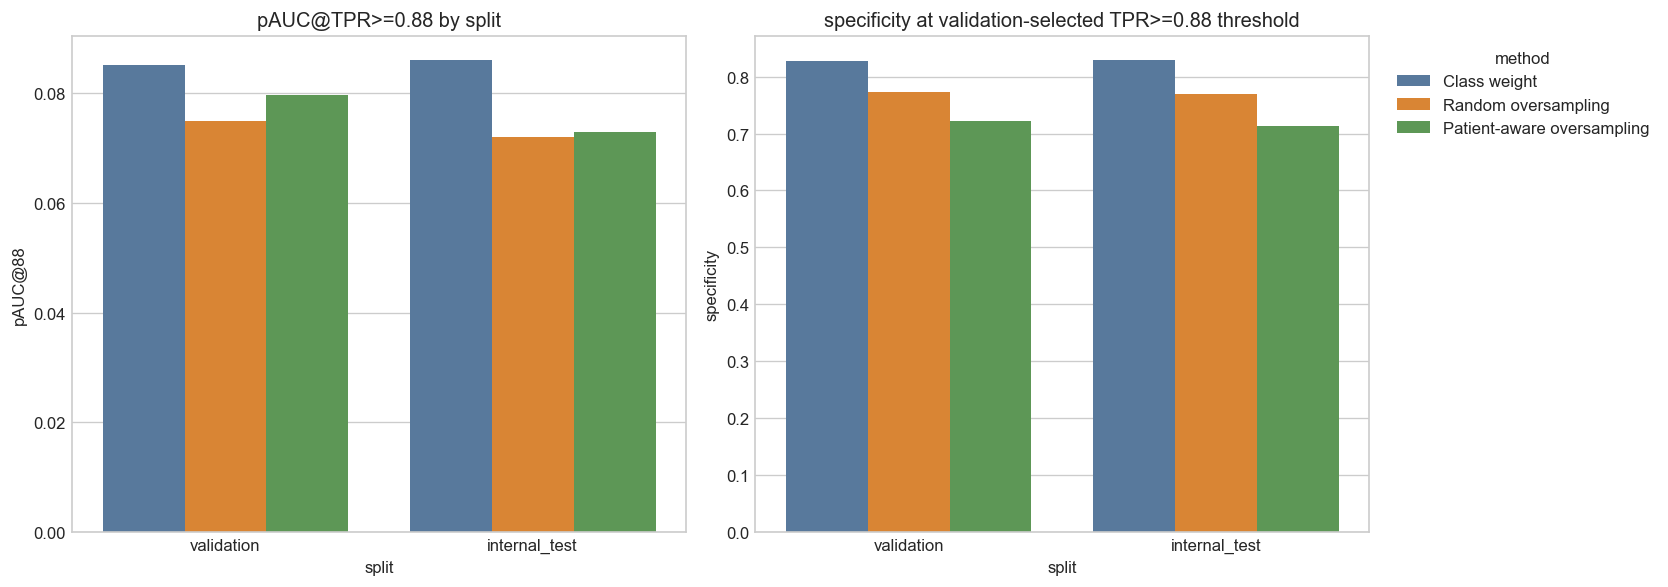

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = metrics_df.copy()

sns.barplot(data=plot_df, x='split', y='pauc_tpr88', hue='method_display', palette=[DISPLAY_COLOR[m] for m in ['class_weight', 'random_oversampling', 'patient_aware_oversampling']], ax=axes[0])
axes[0].set_title('pAUC@TPR>=0.88 by split')
axes[0].set_ylabel('pAUC@88')

sns.barplot(data=plot_df, x='split', y='specificity', hue='method_display', palette=[DISPLAY_COLOR[m] for m in ['class_weight', 'random_oversampling', 'patient_aware_oversampling']], ax=axes[1])
axes[1].set_title('specificity at validation-selected TPR>=0.88 threshold')
axes[1].set_ylabel('specificity')

handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(handles, labels, title='method', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].legend_.remove()
plt.tight_layout()
plt.show()


## 5. 해석 메모

1. `class_weight`는 원래 분포를 유지한 가장 보수적인 baseline이다.
2. `random_oversampling`이 좋아지면, 양성 row 수 자체를 늘리는 것이 도움이 된다는 뜻이다.
3. `patient_aware_oversampling`이 더 좋아지면, 단순 복제보다 `positive patient 편중을 줄이는 방식`이 유리하다는 뜻이다.
4. 반대로 oversampling이 `Strict` 원본 baseline보다 나빠지면, 현재 설정에서는 class weight가 더 안정적이라는 해석이 가능하다.
